# MBDD2025 – Dataset Setup and Exploratory Data Analysis

This notebook performs the initial setup, validation, and exploratory data analysis (EDA) of the MBDD2025 building defects dataset. The goal is to establish a verified metadata baseline and understand the statistical distribution of the data before proceeding to preprocessing, dataset splitting, or model development.

## 1. Environment and Dataset Setup

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image
import random
import kagglehub

# Configuration
RANDOM_SEED = 42
FORCE_REBUILD_METADATA = False
OBJECTS_CSV = "objects_metadata.csv"
IMAGES_CSV = "images_metadata.csv"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Environment configured.")

Environment configured.


### Configure Dataset Paths

The dataset is retrieved via `kagglehub`. We perform dynamic asset discovery to locate the directory structures for images and annotations, ensuring portability across different environments.

In [26]:
# 1. Environment and Dataset Setup

# Download/Use cached dataset
path = kagglehub.dataset_download("mennamahmoudd/mbdd2025-building-defects")
DATASET_ROOT = Path(path)
print(f"Dataset Path: {DATASET_ROOT}")

# Dynamic asset discovery
def find_asset_dir(root, ext):
    for p in root.rglob(f"*{ext}"):
        return p.parent
    return None

IMG_DIR = find_asset_dir(DATASET_ROOT, ".jpg")
XML_DIR = find_asset_dir(DATASET_ROOT, ".xml")
YOLO_DIR = find_asset_dir(DATASET_ROOT, ".txt")

print(f"IMG_DIR: {IMG_DIR}")
print(f"XML_DIR: {XML_DIR}")
print(f"YOLO_DIR: {YOLO_DIR}")

Using Colab cache for faster access to the 'mbdd2025-building-defects' dataset.
Dataset Path: /kaggle/input/mbdd2025-building-defects
IMG_DIR: /kaggle/input/mbdd2025-building-defects/MBDD2025/JPEGImages
XML_DIR: /kaggle/input/mbdd2025-building-defects/MBDD2025/Annotations
YOLO_DIR: /kaggle/input/mbdd2025-building-defects/MBDD2025/Labels


## 2. Dataset Inventory and Pairing Validation

In [27]:
# 2. Dataset Inventory and Pairing Validation

image_files = sorted(list(IMG_DIR.glob("*.jpg")) + list(IMG_DIR.glob("*.jpeg")) + list(IMG_DIR.glob("*.png")))
xml_files = sorted(list(XML_DIR.glob("*.xml")))
yolo_files = sorted(list(YOLO_DIR.glob("*.txt"))) if YOLO_DIR else []

# Create O(1) Lookup Maps
image_map = {f.stem: f for f in image_files}
xml_map = {f.stem: f for f in xml_files}

image_stems = set(image_map.keys())
xml_stems = set(xml_map.keys())

matched_stems = image_stems & xml_stems
xml_no_img = xml_stems - image_stems
img_no_xml = image_stems - xml_stems

# Filename mismatch check
mismatches = []
for stem in matched_stems:
    xml_f = xml_map[stem]
    tree = ET.parse(xml_f)
    root = tree.getroot()
    xml_internal = root.find('filename').text if root.find('filename') is not None else None
    actual_file = image_map[stem].name
    if xml_internal != actual_file:
        mismatches.append({'xml': xml_f.name, 'xml_internal': xml_internal, 'actual_file': actual_file})

print(f"Inventory: {len(image_files)} Images, {len(xml_files)} XMLs, {len(yolo_files)} YOLO labels.")
print(f"Pairs: {len(matched_stems)} matched, {len(xml_no_img)} XML orphaned, {len(img_no_xml)} Images orphaned.")

Inventory: 14471 Images, 14471 XMLs, 14471 YOLO labels.
Pairs: 14471 matched, 0 XML orphaned, 0 Images orphaned.


## 3. Pascal VOC Parsing and Metadata Loading

We generate two canonical metadata tables:
1. **`objects_df`**: Contains one row per individual annotated object (defect instance).
2. **`images_df`**: Contains one row per image, summarizing counts and classes present.

In [28]:
# 3. Metadata Loading / Pascal VOC Parsing

cache_exists = os.path.exists(OBJECTS_CSV) and os.path.exists(IMAGES_CSV)

if cache_exists and not FORCE_REBUILD_METADATA:
    print("Loading cached metadata...")
    objects_df = pd.read_csv(OBJECTS_CSV)
    images_df = pd.read_csv(IMAGES_CSV)
else:
    print("Building metadata from raw dataset...")
    all_objects = []
    for xml_f in xml_files:
        tree = ET.parse(xml_f)
        root = tree.getroot()
        size = root.find('size')
        w = int(size.find('width').text) if size is not None and size.find('width') is not None and size.find('width').text is not None else 0
        h = int(size.find('height').text) if size is not None and size.find('height') is not None and size.find('height').text is not None else 0
        # Fix: Robust check for depth text to avoid TypeError
        d_elem = size.find('depth') if size is not None else None
        d = int(d_elem.text) if d_elem is not None and d_elem.text is not None else None

        for obj in root.findall('object'):
            cls = obj.find('name').text
            bbox = obj.find('bndbox')
            xmin, ymin = float(bbox.find('xmin').text), float(bbox.find('ymin').text)
            xmax, ymax = float(bbox.find('xmax').text), float(bbox.find('ymax').text)
            bw, bh = xmax - xmin, ymax - ymin
            area = bw * bh

            all_objects.append({
                'image_id': xml_f.stem,
                'filename': image_map[xml_f.stem].name if xml_f.stem in image_map else None,
                'xml_name': xml_f.name,
                'width': w, 'height': h, 'depth': d,
                'class': cls, 'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
                'bbox_width': bw, 'bbox_height': bh, 'bbox_area': area,
                'bbox_area_ratio': area / (w * h) if w * h > 0 else 0,
                'bbox_center_x': xmin + bw/2, 'bbox_center_y': ymin + bh/2,
                'bbox_center_x_normalized': (xmin + bw/2) / w if w > 0 else 0,
                'bbox_center_y_normalized': (ymin + bh/2) / h if h > 0 else 0,
                'bbox_aspect_ratio': bw / bh if bh > 0 else 0
            })
    objects_df = pd.DataFrame(all_objects)

    # OPTIMIZATION: Pre-group objects to avoid O(N^2) filtering
    obj_lookup = objects_df.groupby('image_id').agg({
        'class': [list, 'nunique', 'count'],
        'width': 'first',
        'height': 'first'
    })
    obj_lookup.columns = ['classes_present', 'n_unique_classes', 'n_objects', 'image_width', 'image_height']

    # Build Images DF using lookups
    img_data = []
    for f in image_files:
        stem = f.stem
        if stem in obj_lookup.index:
            info = obj_lookup.loc[stem]
            w, h = info['image_width'], info['image_height']
            n_obj, n_uniq = info['n_objects'], info['n_unique_classes']
            classes = tuple(info['classes_present'])
        else:
            with Image.open(f) as img: w, h = img.size
            n_obj, n_uniq, classes = 0, 0, ()

        img_data.append({
            'image_name': f.name, 'image_id': stem, 'image_width': w, 'image_height': h,
            'xml_name': f"{stem}.xml" if stem in xml_stems else None,
            'has_xml': stem in xml_stems,
            'n_objects': n_obj,
            'n_unique_classes': n_uniq,
            'classes_present': classes
        })
    images_df = pd.DataFrame(img_data)

    objects_df.to_csv(OBJECTS_CSV, index=False)
    images_df.to_csv(IMAGES_CSV, index=False)
    print("Metadata built and saved.")

Loading cached metadata...


## 4. Metadata Overview

In [29]:
display(objects_df.head())
display(images_df.head())

print("objects_df shape:", objects_df.shape)
print("images_df shape:", images_df.shape)

,image_id,filename,xml_name,width,height,depth,class,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,bbox_area_ratio,bbox_center_x,bbox_center_y,bbox_center_x_normalized,bbox_center_y_normalized,bbox_aspect_ratio
0,Hefei1,Hefei1.jpg,Hefei1.xml,1280,720,NaN,corrosion,609.72,201.06,691.98,309.81,82.26,108.75,8945.7750,0.009707,650.850,255.435,0.508477,0.354771,0.756414
1,Hefei10,Hefei10.jpg,Hefei10.xml,1280,720,NaN,corrosion,631.88,202.46,707.17,297.26,75.29,94.80,7137.4920,0.007745,669.525,249.860,0.523066,0.347028,0.794198
2,Hefei100,Hefei100.jpg,Hefei100.xml,1280,720,NaN,corrosion,2.38,174.69,44.21,290.87,41.83,116.18,4859.8094,0.005273,23.295,232.780,0.018199,0.323306,0.360045
3,Hefei100,Hefei100.jpg,Hefei100.xml,1280,720,NaN,corrosion,93.01,243.24,242.89,293.20,149.88,49.96,7488.0048,0.008125,167.950,268.220,0.131211,0.372528,3.000000
4,Hefei100,Hefei100.jpg,Hefei100.xml,1280,720,NaN,corrosion,290.53,207.22,335.84,246.72,45.31,39.50,1789.7450,0.001942,313.185,226.970,0.244676,0.315236,1.147089


,image_name,image_id,image_width,image_height,xml_name,has_xml,n_objects,n_unique_classes,classes_present
0,Hefei1.jpg,Hefei1,1280,720,Hefei1.xml,True,1,1,"('corrosion',)"
1,Hefei10.jpg,Hefei10,1280,720,Hefei10.xml,True,1,1,"('corrosion',)"
2,Hefei100.jpg,Hefei100,1280,720,Hefei100.xml,True,5,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
3,Hefei1000.jpg,Hefei1000,1280,720,Hefei1000.xml,True,2,2,"('leakage', 'abscission')"
4,Hefei10000.jpg,Hefei10000,1280,720,Hefei10000.xml,True,3,1,"('crack', 'crack', 'crack')"


objects_df shape: (57613, 20)
images_df shape: (14471, 9)


## 5. Annotation Validation

In [30]:
validation_checks = [
    ('xmin >= xmax', (objects_df['xmin'] >= objects_df['xmax']).sum()),
    ('ymin >= ymax', (objects_df['ymin'] >= objects_df['ymax']).sum()),
    ('xmin < 0', (objects_df['xmin'] < 0).sum()),
    ('ymin < 0', (objects_df['ymin'] < 0).sum()),
    ('xmax > width', (objects_df['xmax'] > objects_df['width']).sum()),
    ('ymax > height', (objects_df['ymax'] > objects_df['height']).sum()),
    ('bbox_area_ratio <= 0', (objects_df['bbox_area_ratio'] <= 0).sum()),
    ('bbox_area_ratio > 1', (objects_df['bbox_area_ratio'] > 1).sum()),
    ('Duplicate Rows', objects_df.duplicated().sum())
]
validation_summary = pd.DataFrame(validation_checks, columns=['check', 'count'])
validation_summary['status'] = validation_summary['count'].apply(lambda x: 'OK' if x == 0 else 'REVIEW')

print("Annotation Validation Summary:")
display(validation_summary)

# Provide a sample of anomalies if they exist
oob_samples = objects_df[(objects_df['xmin'] < 0) | (objects_df['ymin'] < 0) | (objects_df['xmax'] > objects_df['width']) | (objects_df['ymax'] > objects_df['height'])]
if not oob_samples.empty:
    print(f"\nTotal instances requiring review: {len(oob_samples)}")
    display(oob_samples.head(5))

Annotation Validation Summary:


,check,count,status
0,xmin >= xmax,0,OK
1,ymin >= ymax,0,OK
2,xmin < 0,40,REVIEW
3,ymin < 0,32,REVIEW
4,xmax > width,33,REVIEW
5,ymax > height,11,REVIEW
6,bbox_area_ratio <= 0,0,OK
7,bbox_area_ratio > 1,0,OK
8,Duplicate Rows,0,OK



Total instances requiring review: 116


,image_id,filename,xml_name,width,height,depth,class,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,bbox_area_ratio,bbox_center_x,bbox_center_y,bbox_center_x_normalized,bbox_center_y_normalized,bbox_aspect_ratio
7904,Hefei11420,Hefei11420.jpg,Hefei11420.xml,1280,720,NaN,crack,-7.75,135.09,201.80,165.10,209.55,30.01,6288.5955,0.006824,97.025,150.095,0.075801,0.208465,6.982672
7925,Hefei11421,Hefei11421.jpg,Hefei11421.xml,1280,720,NaN,crack,-18.96,127.34,226.97,158.32,245.93,30.98,7618.9114,0.008267,104.005,142.830,0.081254,0.198375,7.938347
7934,Hefei11422,Hefei11422.jpg,Hefei11422.xml,1280,720,NaN,crack,-9.97,118.36,216.08,153.73,226.05,35.37,7995.3885,0.008676,103.055,136.045,0.080512,0.188951,6.391009
7945,Hefei11423,Hefei11423.jpg,Hefei11423.xml,1280,720,NaN,crack,-14.12,110.88,270.54,152.51,284.66,41.63,11850.3958,0.012859,128.210,131.695,0.100164,0.182910,6.837857
7961,Hefei11424,Hefei11424.jpg,Hefei11424.xml,1280,720,NaN,crack,-13.15,103.13,247.30,143.80,260.45,40.67,10592.5015,0.011494,117.075,123.465,0.091465,0.171479,6.403983


## 6. Ground Truth Annotation Sanity Check

Visualizing Ground Truth annotations (Dataset Labels):


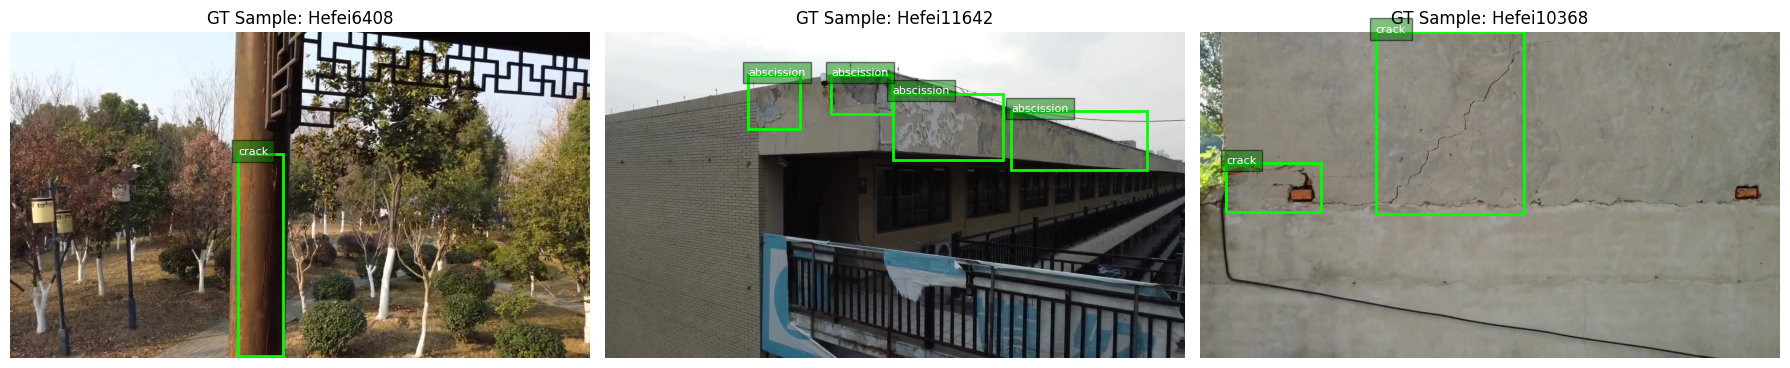

In [31]:
def visualize_gt_sample(n=3):
    # Local deterministic generator for reproducibility
    rng = random.Random(42)
    valid_ids = images_df[images_df['n_objects'] > 0]['image_id'].tolist()
    sample_ids = rng.sample(valid_ids, min(n, len(valid_ids)))

    plt.figure(figsize=(18, 6))
    for i, img_id in enumerate(sample_ids):
        img_path = image_map[img_id]
        img = Image.open(img_path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)

        objs = objects_df[objects_df['image_id'] == img_id]
        for _, obj in objs.iterrows():
            plt.gca().add_patch(plt.Rectangle((obj['xmin'], obj['ymin']),
                                              obj['bbox_width'], obj['bbox_height'],
                                              fill=False, color='lime', linewidth=2))
            plt.text(obj['xmin'], obj['ymin'], obj['class'], color='white',
                     fontsize=8, bbox=dict(facecolor='green', alpha=0.5))
        plt.title(f"GT Sample: {img_id}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Visualizing Ground Truth annotations (Dataset Labels):")
visualize_gt_sample(n=3)

## 7. Dataset Composition

We summarize the high-level metrics of the dataset and inspect image resolution frequencies.

In [32]:
composition = pd.Series({
    'Total Images': len(images_df),
    'Total Objects': len(objects_df),
    'Defect Classes': objects_df['class'].nunique(),
    'Images with Objects': (images_df['n_objects'] > 0).sum(),
    'Images with Zero Objects': (images_df['n_objects'] == 0).sum(),
    'Avg Objects per Image': objects_df.shape[0] / len(images_df),
    'Median Objects per Image': images_df['n_objects'].median(),
    'Max Objects in Image': images_df['n_objects'].max()
})
display(composition)

print("\nImage Resolution Frequencies:")
res_freq = images_df.groupby(['image_width', 'image_height']).size().reset_index(name='count')
display(res_freq.sort_values('count', ascending=False))

,0
Total Images,14471.000000
Total Objects,57613.000000
Defect Classes,5.000000
Images with Objects,14463.000000
Images with Zero Objects,8.000000
Avg Objects per Image,3.981273
Median Objects per Image,2.000000
Max Objects in Image,84.000000



Image Resolution Frequencies:


,image_width,image_height,count
2,1280,720,14102
0,720,1280,254
1,960,544,115


## 8. Class Distribution

Object-level and image-level class frequencies are analyzed separately because multiple instances of the same defect may occur within a single image. This distinction is critical for understanding both class imbalance and image complexity.

,object_count,image_count,object_percentage,image_percentage
abscission,22702,22702,39.404301,156.879276
crack,17044,17044,29.583601,117.780388
corrosion,9207,9207,15.980768,63.623799
leakage,6642,6642,11.528648,45.898694
bulge,2018,2018,3.502682,13.945132


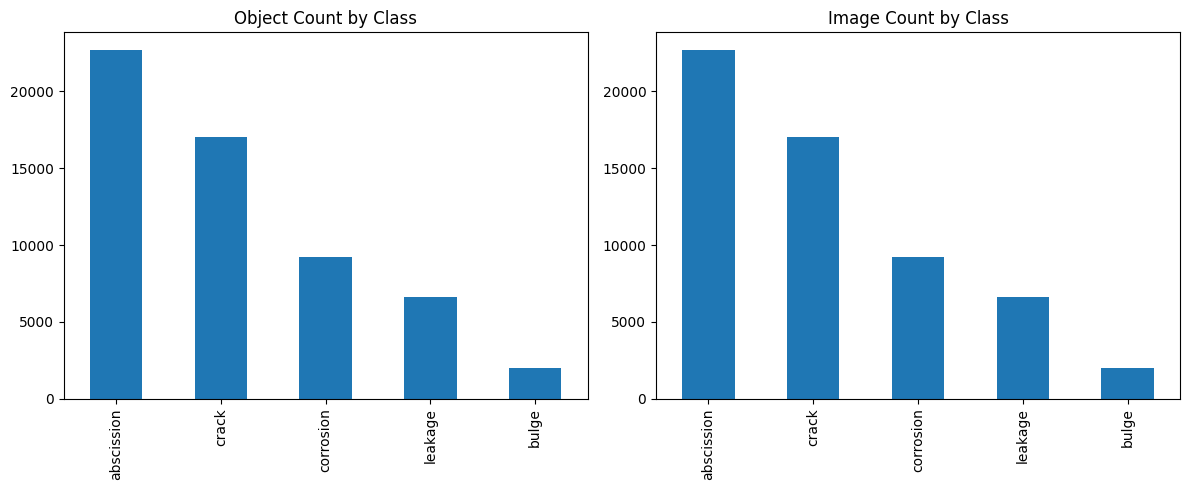

Imbalance Ratio (Largest/Smallest class): 11.25


In [33]:
# 8. Class Distribution
import ast

def parse_classes(c):
    if isinstance(c, (tuple, list)): return c
    try: return ast.literal_eval(c)
    except: return ()

# Extract and count classes robustly
img_classes_series = images_df['classes_present'].apply(parse_classes).explode()
img_counts = img_classes_series.value_counts()
obj_counts = objects_df['class'].value_counts()

valid_defect_classes = ['crack', 'leakage', 'abscission', 'corrosion', 'bulge']
class_distribution_df = pd.DataFrame({
    'object_count': obj_counts,
    'image_count': img_counts
}).fillna(0)
class_distribution_df = class_distribution_df.loc[class_distribution_df.index.isin(valid_defect_classes)]

class_distribution_df['object_percentage'] = (class_distribution_df['object_count'] / len(objects_df)) * 100
class_distribution_df['image_percentage'] = (class_distribution_df['image_count'] / len(images_df)) * 100

display(class_distribution_df)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
class_distribution_df['object_count'].sort_values(ascending=False).plot(kind='bar')
plt.title("Object Count by Class")

plt.subplot(1, 2, 2)
class_distribution_df['image_count'].sort_values(ascending=False).plot(kind='bar')
plt.title("Image Count by Class")
plt.tight_layout()
plt.show()

min_objs = class_distribution_df['object_count'].min()
imbalance_ratio = class_distribution_df['object_count'].max() / min_objs if min_objs > 0 else float('inf')
print(f"Imbalance Ratio (Largest/Smallest class): {imbalance_ratio:.2f}")

# Exploratory Data Analysis

The following sections analyze the dataset's statistical characteristics using the generated metadata to identify patterns, imbalances, and spatial tendencies.

## 9. Objects per Image

We examine the density of defects per image, identifying both empty images and highly crowded ones.

,n_objects
count,14471.000000
mean,3.981273
std,4.778132
min,0.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,84.000000


Zero Objects: 0.06%
Exactly One: 28.20%
Multiple: 71.74%


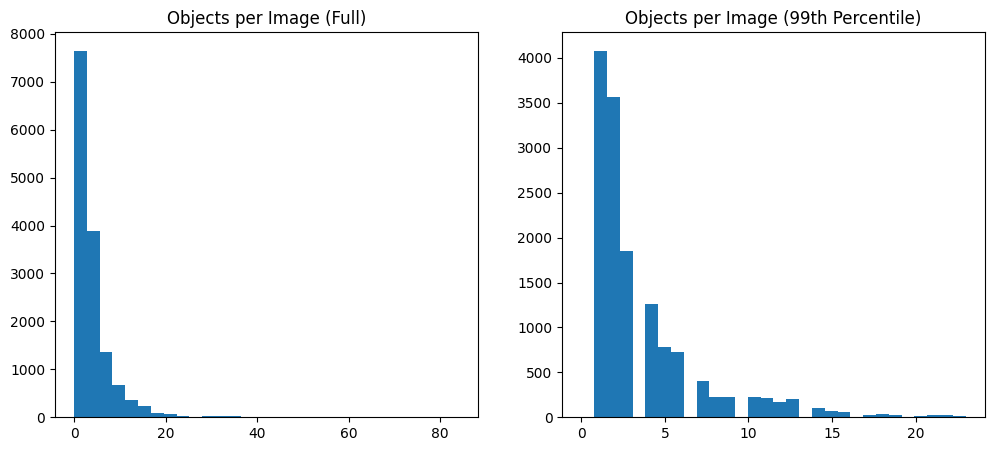


Top 10 Most Crowded Images:


,image_id,n_objects,n_unique_classes,classes_present
4187,Hefei13767,84,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4296,Hefei13865,68,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4206,Hefei13784,66,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4189,Hefei13769,64,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4295,Hefei13864,62,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4186,Hefei13766,60,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4208,Hefei13786,58,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4299,Hefei13868,57,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4288,Hefei13858,55,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."
4191,Hefei13770,52,1,"('corrosion', 'corrosion', 'corrosion', 'corro..."


In [34]:
display(images_df['n_objects'].describe())

print(f"Zero Objects: {(images_df['n_objects'] == 0).mean()*100:.2f}%")
print(f"Exactly One: {(images_df['n_objects'] == 1).mean()*100:.2f}%")
print(f"Multiple: {(images_df['n_objects'] > 1).mean()*100:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(images_df['n_objects'], bins=30)
plt.title("Objects per Image (Full)")

plt.subplot(1, 2, 2)
p99 = images_df['n_objects'].quantile(0.99)
plt.hist(images_df[images_df['n_objects'] <= p99]['n_objects'], bins=30)
plt.title("Objects per Image (99th Percentile)")
plt.show()

print("\nTop 10 Most Crowded Images:")
display(images_df.sort_values('n_objects', ascending=False)[['image_id', 'n_objects', 'n_unique_classes', 'classes_present']].head(10))

## 10. Bounding Box Size Analysis

We use the area ratio (bbox area / full image area) to measure relative defect size.

,bbox_area_ratio
count,57613.000000
mean,0.032810
std,0.065468
min,0.000004
25%,0.003801
50%,0.011452
75%,0.033355
max,1.000000


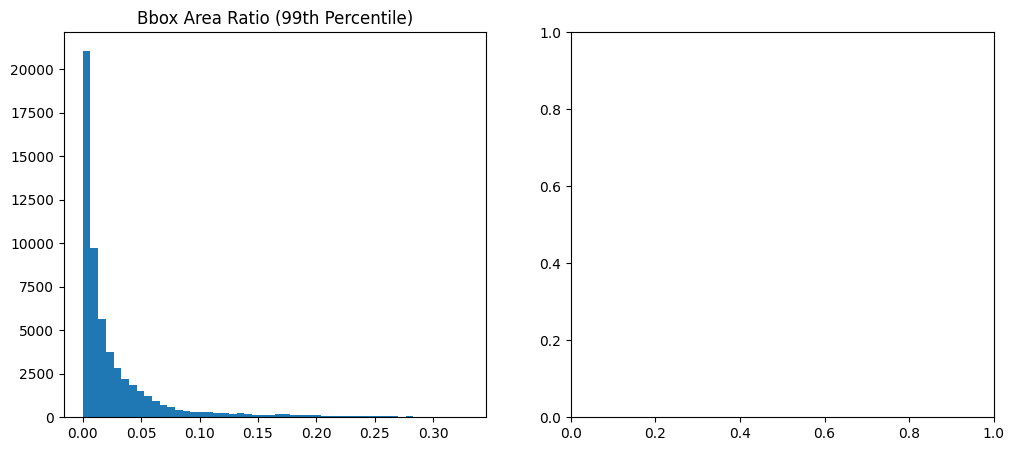

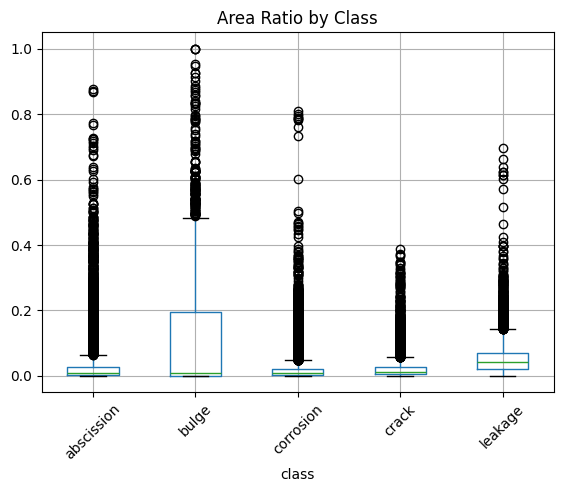

Median Area Ratio by Class:


,bbox_area_ratio
class,
abscission,0.007425
bulge,0.008881
corrosion,0.008884
crack,0.011455
leakage,0.041019



Aspect Ratio Statistics:


,bbox_aspect_ratio
count,57613.000000
mean,2.869637
std,3.885074
min,0.025822
25%,0.722318
50%,1.535605
75%,3.311105
max,48.893448


In [35]:
display(objects_df['bbox_area_ratio'].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
p99_area = objects_df['bbox_area_ratio'].quantile(0.99)
plt.hist(objects_df[objects_df['bbox_area_ratio'] <= p99_area]['bbox_area_ratio'], bins=50)
plt.title("Bbox Area Ratio (99th Percentile)")

plt.subplot(1, 2, 2)
objects_df.boxplot(column='bbox_area_ratio', by='class', rot=45)
plt.title("Area Ratio by Class")
plt.suptitle("") # Clean default title
plt.show()

median_area_by_class = objects_df.groupby('class')['bbox_area_ratio'].median().sort_values()
print("Median Area Ratio by Class:")
display(median_area_by_class)

print("\nAspect Ratio Statistics:")
display(objects_df['bbox_aspect_ratio'].describe())

## 11. Bounding Box Spatial Distribution

We analyze the spatial density of bounding box centers within normalized image coordinates.

Centers outside [0,1]: X=0, Y=0


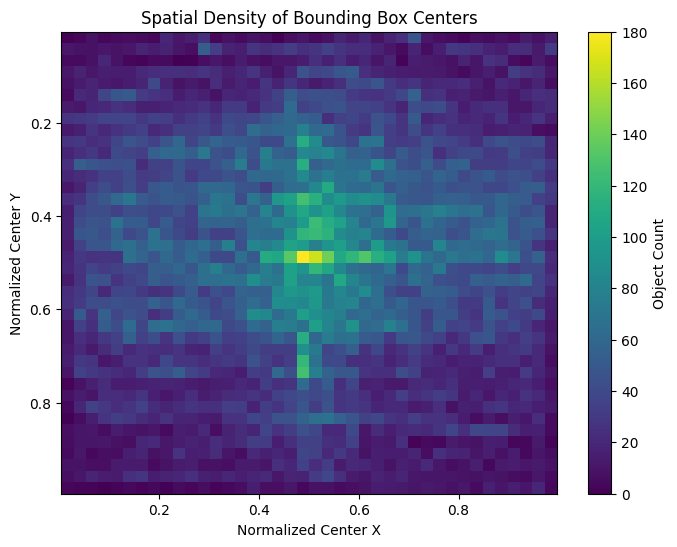

Percentage of objects in central region: 44.11%


In [36]:
oob_x = ((objects_df['bbox_center_x_normalized'] < 0) | (objects_df['bbox_center_x_normalized'] > 1)).sum()
oob_y = ((objects_df['bbox_center_y_normalized'] < 0) | (objects_df['bbox_center_y_normalized'] > 1)).sum()
print(f"Centers outside [0,1]: X={oob_x}, Y={oob_y}")

plt.figure(figsize=(8, 6))
plt.hist2d(objects_df['bbox_center_x_normalized'], objects_df['bbox_center_y_normalized'], bins=40, cmap='viridis')
plt.gca().invert_yaxis()
plt.colorbar(label='Object Count')
plt.xlabel("Normalized Center X")
plt.ylabel("Normalized Center Y")
plt.title("Spatial Density of Bounding Box Centers")
plt.show()

central_count = ((objects_df['bbox_center_x_normalized'] >= 0.25) &
                 (objects_df['bbox_center_x_normalized'] <= 0.75) &
                 (objects_df['bbox_center_y_normalized'] >= 0.25) &
                 (objects_df['bbox_center_y_normalized'] <= 0.75)).sum()
print(f"Percentage of objects in central region: {(central_count/len(objects_df))*100:.2f}%")

## 12. Class Co-occurrence

We analyze which defect types tend to appear together in the same image.

Class Co-occurrence Matrix (Image Counts):


,abscission,bulge,corrosion,crack,leakage
abscission,5166,587,216,1332,129
bulge,587,1337,3,282,9
corrosion,216,3,2102,267,55
crack,1332,282,267,6253,467
leakage,129,9,55,467,2464


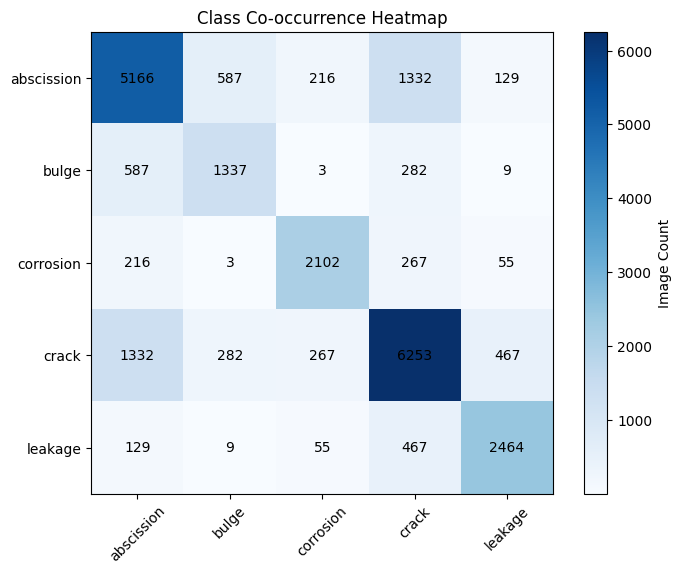


Top 10 Class Combinations:


,class_combination,image_count,percentage
0,crack,4363,30.149955
1,abscission,3340,23.080644
2,leakage,1949,13.468316
3,corrosion,1662,11.485039
4,"abscission, crack",924,6.385184
5,bulge,750,5.182779
6,"crack, leakage",349,2.411720
7,"abscission, bulge",305,2.107664
8,"abscission, bulge, crack",270,1.865801
9,"corrosion, crack",187,1.292240


In [37]:
# 12. Class Co-occurrence analysis
import ast
classes = sorted(['crack', 'leakage', 'abscission', 'corrosion', 'bulge'])

def parse_classes(c):
    if isinstance(c, (list, tuple)): return c
    try: return ast.literal_eval(c)
    except: return ()

presence_data = []
for _, row in images_df.iterrows():
    current = parse_classes(row['classes_present'])
    presence_data.append({cls: (1 if cls in current else 0) for cls in classes})
presence = pd.DataFrame(presence_data)

cooccurrence = presence.T @ presence
print("Class Co-occurrence Matrix (Image Counts):")
display(cooccurrence)

plt.figure(figsize=(8, 6))
plt.imshow(cooccurrence, cmap='Blues', interpolation='nearest')
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, int(cooccurrence.iloc[i, j]), ha="center", va="center")
plt.colorbar(label='Image Count')
plt.title("Class Co-occurrence Heatmap")
plt.show()

# Combination Analysis (without modifying images_df permanently)
temp_combos = images_df['classes_present'].apply(lambda x: ", ".join(sorted(list(set(parse_classes(x))))) or "None")
combo_counts = temp_combos.value_counts().reset_index()
combo_counts.columns = ['class_combination', 'image_count']
combo_counts['percentage'] = (combo_counts['image_count'] / len(images_df)) * 100

print("\nTop 10 Class Combinations:")
display(combo_counts.head(10))

## 13. Initial EDA Findings

Factual summary of observations from the preliminary data analysis.

In [38]:
# 13. Initial EDA Findings

findings = pd.Series({
    'Total Images': len(images_df),
    'Total Objects': len(objects_df),
    'Most Common Class': class_distribution_df['object_count'].idxmax(),
    'Least Common Class': class_distribution_df['object_count'].idxmin(),
    'Imbalance Ratio': imbalance_ratio,
    'Images with Multiple Objects': (images_df['n_objects'] > 1).sum(),
    'Images with Multiple Classes': (images_df['n_unique_classes'] > 1).sum(),
    'Max Objects/Image': images_df['n_objects'].max(),
    'Primary Resolution': f"{res_freq.sort_values('count', ascending=False).iloc[0]['image_width']}x{res_freq.sort_values('count', ascending=False).iloc[0]['image_height']}",
    'Median Area Ratio': objects_df['bbox_area_ratio'].median(),
    'Central Region Concentration (%)': (central_count/len(objects_df))*100,
    'Validation Review Required': validation_summary[validation_summary['status'] == 'REVIEW']['count'].sum()
})

print("--- Final Initial EDA Findings ---")
display(findings)

--- Final Initial EDA Findings ---


,0
Total Images,14471
Total Objects,57613
Most Common Class,abscission
Least Common Class,bulge
Imbalance Ratio,11.249752
Images with Multiple Objects,10382
Images with Multiple Classes,2399
Max Objects/Image,84
Primary Resolution,1280x720
Median Area Ratio,0.011452


## 14. EDA Summary and Interpretation

The initial EDA provides a clear picture of the main characteristics of MBDD2025 before model development.

The dataset contains **14,471 UAV images and 57,613 annotated defects** across five classes. The class distribution is noticeably imbalanced: **abscission and crack are the most represented classes, while bulge is significantly less common**. This imbalance will be important when evaluating future model performance across individual classes.

The dataset is strongly **multi-object**. Many images contain several defect instances, although they often belong to the same defect class rather than several different classes. Object density also varies considerably, with a small number of images containing unusually large numbers of annotations.

Most defects occupy a **relatively small portion of the image**, and bounding-box size differs between classes. The annotations also show some concentration toward the central region of the UAV images. These characteristics may influence detection performance and should be considered during later error analysis.

Overall, the dataset appears well structured. Only a small number of bounding boxes were flagged for extending beyond image boundaries, and these should be reviewed before training rather than automatically removed or corrected.

### Key Takeaways

- Significant class imbalance exists between defect categories.
- Images frequently contain multiple defect instances.
- Many annotated defects are relatively small compared with the full UAV frame.
- Bounding-box size and shape vary between classes.
- Annotation locations show some spatial concentration toward the image center.
- A small number of annotation boundary issues require review.

These findings establish the dataset baseline. **No preprocessing, balancing, splitting, or modeling decisions are made at this stage.**

## Next Step

The initial EDA identified class imbalance, variation in object scale and density, spatial concentration of annotations, and a small number of annotation-quality issues requiring review.

Because MBDD2025 was acquired using overlapping UAV imagery, the next stage of the project will investigate frame continuity and potential sequence structure before defining the train/validation/test split.